Решается задача исследования уверенности модели при классификации текстов. В качестве базовой модели выбрана Qwen2.5-1.5B-Instruct. Мы тестируем метод "Self-Consistency", для тестирования используется датасетах ai-forever/ru-scibench-grnti-classification и CLINC-150. Возьмём из них по 10 классов.

# Считыввание данных


In [1]:
import pandas as pd

# train_df = pd.read_csv("train_c.csv")
test_df = pd.read_csv("test_c.csv")
# train_df = pd.read_csv("train_grnti.csv")
# test_df = pd.read_csv("test_grnti.csv")

print("Размер test:", test_df.shape)
print(test_df.head())

Размер test: (100, 3)
    id                                               text        label
0  297            Можешь найти мне рецепт медового хлеба?       рецепт
1  794                    Вы можете рассчитать мой налог?       налоги
2  805  Нужно ли мне делать прививки или что-то еще пе...      вакцины
3   46             что осталось на моих банковских счетах       баланс
4  998  Можете ли вы сказать мне все напоминания я уст...  напоминание


In [2]:
!pip install transformers accelerate torch pandas tqdm

import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import time

In [3]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

# Self-Consistency, grnti, 0.5


In [ ]:
def create_prompt(text, classes):
    instruction = f"""Ты — эксперт по научной классификации. Твоя задача — отнести научную статью к одной из рубрик.

Доступные рубрики: {', '.join(classes)}.

Классифицируй следующий текст по одной из категорий.
Ответь только одним словом — названием категории, без дополнительных слов, знаков препинания или форматирования.

Примеры:
Текст: Исследование свойств полимеров
Категория: Химия

Текст: Квантовая теория поля
Категория: Физика

Теперь классифицируй следующий текст:

Текст: {text}

Категория:"""
    return instruction

In [ ]:
classes = [
    "Энергетика",
    "Языкознание",
    "Психология",
    "Философия",
    "Биология",
    "Геология",
    "Химия",
    "Транспорт",
    "Физика",
    "Математика"
]

In [ ]:
def extract_category(generated_text, classes):
    """
    Извлекает категорию из сгенерированного текста.
    Ищет первое вхождение любого класса из списка (регистронезависимо).
    Если не найдено, возвращает 'unknown'.
    """
    cleaned = generated_text.strip()
    # Ищем класс в тексте (можно убрать звёздочки, но не обязательно)
    for cls in classes:
        if cls.lower() in cleaned.lower():
            return cls
    return "unknown"

In [ ]:
def generate_single_prediction(text, classes, temperature=0.5, do_sample=True):
    prompt = create_prompt(text, classes)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=18,          # достаточно для одного слова
            temperature=temperature,
            do_sample=do_sample,
            pad_token_id=tokenizer.eos_token_id
        )
    generated = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    # Извлекаем категорию
    category = extract_category(generated, classes)
    return category

In [ ]:
def generate_multiple_predictions(text, classes, M=5, temperature=1.0):
    preds = []
    for _ in range(M):
        pred = generate_single_prediction(text, classes, temperature=temperature, do_sample=True)
        preds.append(pred)
    return preds

In [ ]:
from collections import Counter
import math

def consistency_metrics(predictions):
    """
    predictions: list of strings
    возвращает словарь с метриками
    """
    if not predictions:
        return {"majority_vote": None, "confidence": 0.0, "entropy": float('inf'), "unique_ratio": 1.0}

    counter = Counter(predictions)
    majority_class, majority_count = counter.most_common(1)[0]
    total = len(predictions)
    confidence = majority_count / total          # доля совпадающих с мажоритарным
    entropy = -sum((cnt/total) * math.log(cnt/total) for cnt in counter.values())
    unique_ratio = len(counter) / total          # доля уникальных ответов

    return {
        "majority_vote": majority_class,
        "confidence": confidence,
        "entropy": entropy,
        "unique_ratio": unique_ratio
    }

In [ ]:
def measure_inference_speed(text, classes, M=5, num_runs=5):
    """Измеряет среднее время выполнения M генераций для одного примера."""
    times = []
    for _ in range(num_runs):
        start = time.time()
        generate_multiple_predictions(text, classes, M=M)
        end = time.time()
        times.append(end - start)
    avg_time = np.mean(times)
    std_time = np.std(times)
    return avg_time, std_time

Размер test: (1000, 3)
       id                                               text  label
0  178587  ВЫСОКОВОЛЬТНЫЕ ЯВЛЕНИЯ В РАСПЛАВЛЕННЫХ ХЛОРИДН...  Химия
1   61924  Каталитическое карбонилирование α-олефинов в п...  Химия
2  165778  ВЛИЯНИЕ ТЕМПЕРАТУРЫ И КОНЦЕНТРАЦИИ НА ГИДРАТАЦ...  Химия
3  126942  ОПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ ДИФФУЗИИ АМЕРИЦИЯ И ...  Химия
4   54173  ОБЩЕЕ ПРЕДСТАВЛЕНИЕ О НУКЛЕАЗАХ ИЗ ЯДА ЗМЕЙ: Д...  Химия
Классы: ['Энергетика', 'Языкознание', 'Психология', 'Философия', 'Биология', 'Геология', 'Химия', 'Транспорт', 'Физика', 'Математика']


100%|██████████| 1000/1000 [2:41:01<00:00,  9.66s/it]
/tmp/ipykernel_3233/2356358597.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auarc = np.trapz(accuracies, x=rejection_rates)


AUROC (confidence): 0.7551
AUROC (certainty): 0.7596
AUARC (confidence): 0.7386

Всего примеров: 1000
Всего генераций: 10000
Общее время: 9661.53 сек
Среднее на пример: 9.662 сек
Среднее на одну генерацию: 0.966 сек


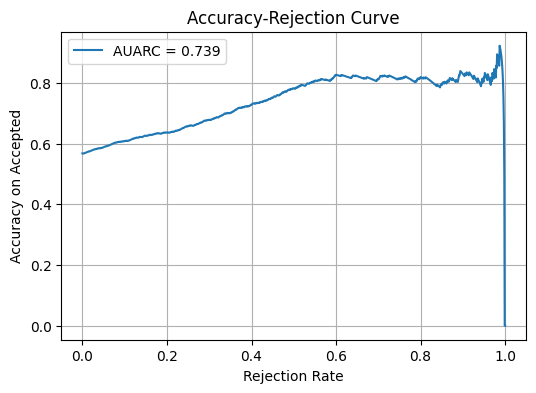

In [ ]:
import time
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# --- Ваш существующий код (чтение датасета, определение классов, инициализация модели) ---
# ...
test_df = pd.read_csv("test_grnti.csv")
print("Размер test:", test_df.shape)
print(test_df.head())


print("Классы:", classes)


# Параметры
M = 10
temperature = 0.5
N = len(test_df)   # можно взять весь датасет или его часть
sample_df = test_df.head(N)

results = []
start_time = time.time()

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    text = row['text']
    true_label = row['label']
    preds = generate_multiple_predictions(text, classes, M=M, temperature=temperature)
    metrics = consistency_metrics(preds)
    results.append({
        'text': text,
        'true_label': true_label,
        'predictions': preds,
        'majority_vote': metrics['majority_vote'],
        'confidence': metrics['confidence'],
        'entropy': metrics['entropy'],
        'unique_ratio': metrics['unique_ratio']
    })

end_time = time.time()
total_time = end_time - start_time
n_examples = len(sample_df)

results_df = pd.DataFrame(results)
results_df['is_correct'] = (results_df['majority_vote'] == results_df['true_label']).astype(int)

# --- Метрики качества ---
auroc_conf = roc_auc_score(results_df['is_correct'], results_df['confidence'])
max_entropy = np.log(len(classes))
results_df['certainty'] = 1 - results_df['entropy'] / max_entropy
auroc_entropy = roc_auc_score(results_df['is_correct'], results_df['certainty'])

print(f"AUROC (confidence): {auroc_conf:.4f}")
print(f"AUROC (certainty): {auroc_entropy:.4f}")

def compute_auarc(df, confidence_col='confidence', correct_col='is_correct'):
    sorted_df = df.sort_values(by=confidence_col, ascending=False).reset_index(drop=True)
    n = len(sorted_df)
    accuracies = []
    rejection_rates = []
    for k in range(n + 1):
        accepted = sorted_df.iloc[:n-k]
        if len(accepted) == 0:
            acc = 0.0
        else:
            acc = accepted[correct_col].mean()
        accuracies.append(acc)
        rejection_rates.append(k / n)
    auarc = np.trapz(accuracies, x=rejection_rates)
    return auarc, rejection_rates, accuracies

auarc_conf, rej_rates, acc_vals = compute_auarc(results_df, confidence_col='confidence')
print(f"AUARC (confidence): {auarc_conf:.4f}")

# --- Скорость инференса ---
print(f"\nВсего примеров: {n_examples}")
print(f"Всего генераций: {n_examples * M}")
print(f"Общее время: {total_time:.2f} сек")
print(f"Среднее на пример: {total_time / n_examples:.3f} сек")
print(f"Среднее на одну генерацию: {total_time / (n_examples * M):.3f} сек")

# --- (Опционально) График ARC ---
plt.figure(figsize=(6, 4))
plt.plot(rej_rates, acc_vals, label=f'AUARC = {auarc_conf:.3f}')
plt.xlabel('Rejection Rate')
plt.ylabel('Accuracy on Accepted')
plt.title('Accuracy-Rejection Curve')
plt.legend()
plt.grid(True)
plt.show()

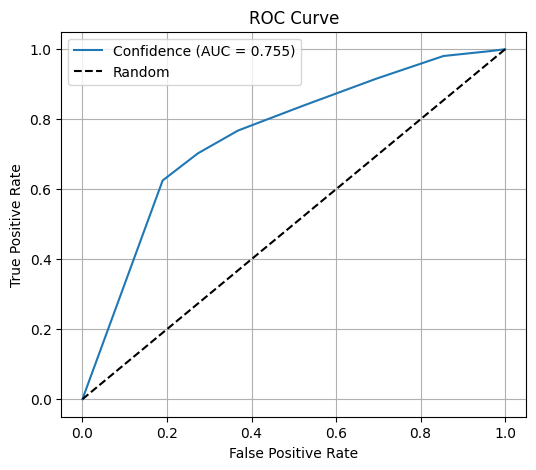

In [ ]:
from sklearn.metrics import roc_curve, auc

# ROC для confidence
fpr_conf, tpr_conf, _ = roc_curve(results_df['is_correct'], results_df['confidence'])
roc_auc_conf = auc(fpr_conf, tpr_conf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_conf, tpr_conf, label=f'Confidence (AUC = {roc_auc_conf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# # Загружаем датасет
# test_df = pd.read_csv("test_grnti.csv")
# print("Размер test:", test_df.shape)
# print(test_df.head())


# print("Классы:", classes)

# # Для теста возьмём первые N примеров
# N = len(test_df)  # можно изменить
# sample_df = test_df.head(N)

# # Параметры
# M = 10
# temperature = 0.5   # степень стохастичности

# # Сохраняем результаты
# results = []

# # Прогресс-бар
# for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
#     text = row['text']
#     true_label = row['label']

#     # Генерация M предсказаний
#     preds = generate_multiple_predictions(text, classes, M=M, temperature=temperature)

#     # Метрики согласованности
#     metrics = consistency_metrics(preds)

#     # Запоминаем
#     results.append({
#         'text': text,
#         'true_label': true_label,
#         'predictions': preds,
#         'majority_vote': metrics['majority_vote'],
#         'confidence': metrics['confidence'],
#         'entropy': metrics['entropy'],
#         'unique_ratio': metrics['unique_ratio']
#     })

# # Преобразуем в DataFrame для анализа
# results_df = pd.DataFrame(results)
# print(results_df[['true_label', 'majority_vote', 'confidence', 'entropy', 'unique_ratio']].head(10))

In [ ]:
results_df

,text,true_label,predictions,majority_vote,confidence,entropy,unique_ratio,is_correct,certainty
0,ВЫСОКОВОЛЬТНЫЕ ЯВЛЕНИЯ В РАСПЛАВЛЕННЫХ ХЛОРИДН...,Химия,"[Химия, Химия, Физика, Химия, Химия, Химия, Хи...",Химия,0.8,0.500402,0.2,1,0.782678
1,Каталитическое карбонилирование α-олефинов в п...,Химия,"[Химия, Химия, Химия, Химия, Химия, Химия, Хим...",Химия,1.0,-0.000000,0.1,1,1.000000
2,ВЛИЯНИЕ ТЕМПЕРАТУРЫ И КОНЦЕНТРАЦИИ НА ГИДРАТАЦ...,Химия,"[Химия, Химия, Химия, Химия, Химия, Химия, Хим...",Химия,1.0,-0.000000,0.1,1,1.000000
3,ОПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ ДИФФУЗИИ АМЕРИЦИЯ И ...,Химия,"[Физика, Химия, Химия, Химия, Химия, Химия, Фи...",Химия,0.8,0.500402,0.2,1,0.782678
4,ОБЩЕЕ ПРЕДСТАВЛЕНИЕ О НУКЛЕАЗАХ ИЗ ЯДА ЗМЕЙ: Д...,Химия,"[Физика, Биология, Биология, Биология, Физика,...",Физика,0.6,0.673012,0.2,0,0.707715
...,...,...,...,...,...,...,...,...,...
995,Демокрит и дата падения Трои. В статье рассмат...,Философия,"[Философия, Философия, Философия, Философия, Ф...",Философия,1.0,-0.000000,0.1,1,1.000000
996,ФИЛОСОФИЯ ИСТОРИИ Н.А. БЕРДЯЕВА: ЭКЗИСТЕНЦИАЛЬ...,Философия,"[Философия, Философия, Философия, Философия, Ф...",Философия,1.0,-0.000000,0.1,1,1.000000
997,Проблема императивности в этике Аристотеля. Це...,Философия,"[Философия, Философия, Философия, Философия, Ф...",Философия,1.0,-0.000000,0.1,1,1.000000
998,Тактика вне стратегии. Военно-политическая раб...,Философия,"[unknown, unknown, unknown, unknown, unknown, ...",unknown,1.0,-0.000000,0.1,0,1.000000


In [ ]:
results_df["predictions"][:6]

,predictions
0,"[Химия, Химия, Физика, Химия, Химия, Химия, Хи..."
1,"[Химия, Химия, Химия, Химия, Химия, Химия, Хим..."
2,"[Химия, Химия, Химия, Химия, Химия, Химия, Хим..."
3,"[Физика, Химия, Химия, Химия, Химия, Химия, Фи..."
4,"[Физика, Биология, Биология, Биология, Физика,..."
5,"[Химия, Химия, Математика, Биология, Математик..."


# Self-Consistency, grnti, 1


In [ ]:
def create_prompt(text, classes):
    instruction = f"""Ты — эксперт по научной классификации. Твоя задача — отнести научную статью к одной из рубрик.

Доступные рубрики: {', '.join(classes)}.

Классифицируй следующий текст по одной из категорий.
Ответь только одним словом — названием категории, без дополнительных слов, знаков препинания или форматирования.

Примеры:
Текст: Исследование свойств полимеров
Категория: Химия

Текст: Квантовая теория поля
Категория: Физика

Теперь классифицируй следующий текст:

Текст: {text}

Категория:"""
    return instruction

In [ ]:
classes = [
    "Энергетика",
    "Языкознание",
    "Психология",
    "Философия",
    "Биология",
    "Геология",
    "Химия",
    "Транспорт",
    "Физика",
    "Математика"
]

In [ ]:
def extract_category(generated_text, classes):
    """
    Извлекает категорию из сгенерированного текста.
    Ищет первое вхождение любого класса из списка (регистронезависимо).
    Если не найдено, возвращает 'unknown'.
    """
    cleaned = generated_text.strip()
    # Ищем класс в тексте (можно убрать звёздочки, но не обязательно)
    for cls in classes:
        if cls.lower() in cleaned.lower():
            return cls
    return "unknown"

In [ ]:
def generate_single_prediction(text, classes, temperature=1, do_sample=True):
    prompt = create_prompt(text, classes)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=18,          # достаточно для одного слова
            temperature=temperature,
            do_sample=do_sample,
            pad_token_id=tokenizer.eos_token_id
        )
    generated = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    # Извлекаем категорию
    category = extract_category(generated, classes)
    return category

In [ ]:
def generate_multiple_predictions(text, classes, M=5, temperature=1.0):
    preds = []
    for _ in range(M):
        pred = generate_single_prediction(text, classes, temperature=temperature, do_sample=True)
        preds.append(pred)
    return preds

In [ ]:
from collections import Counter
import math

def consistency_metrics(predictions):
    """
    predictions: list of strings
    возвращает словарь с метриками
    """
    if not predictions:
        return {"majority_vote": None, "confidence": 0.0, "entropy": float('inf'), "unique_ratio": 1.0}

    counter = Counter(predictions)
    majority_class, majority_count = counter.most_common(1)[0]
    total = len(predictions)
    confidence = majority_count / total          # доля совпадающих с мажоритарным
    entropy = -sum((cnt/total) * math.log(cnt/total) for cnt in counter.values())
    unique_ratio = len(counter) / total          # доля уникальных ответов

    return {
        "majority_vote": majority_class,
        "confidence": confidence,
        "entropy": entropy,
        "unique_ratio": unique_ratio
    }

In [ ]:
def measure_inference_speed(text, classes, M=5, num_runs=5):
    """Измеряет среднее время выполнения M генераций для одного примера."""
    times = []
    for _ in range(num_runs):
        start = time.time()
        generate_multiple_predictions(text, classes, M=M)
        end = time.time()
        times.append(end - start)
    avg_time = np.mean(times)
    std_time = np.std(times)
    return avg_time, std_time

Размер test: (1000, 3)
       id                                               text  label
0  178587  ВЫСОКОВОЛЬТНЫЕ ЯВЛЕНИЯ В РАСПЛАВЛЕННЫХ ХЛОРИДН...  Химия
1   61924  Каталитическое карбонилирование α-олефинов в п...  Химия
2  165778  ВЛИЯНИЕ ТЕМПЕРАТУРЫ И КОНЦЕНТРАЦИИ НА ГИДРАТАЦ...  Химия
3  126942  ОПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ ДИФФУЗИИ АМЕРИЦИЯ И ...  Химия
4   54173  ОБЩЕЕ ПРЕДСТАВЛЕНИЕ О НУКЛЕАЗАХ ИЗ ЯДА ЗМЕЙ: Д...  Химия
Классы: ['Энергетика', 'Языкознание', 'Психология', 'Философия', 'Биология', 'Геология', 'Химия', 'Транспорт', 'Физика', 'Математика']


100%|██████████| 1000/1000 [2:21:44<00:00,  8.50s/it]
/tmp/ipykernel_5355/2148254784.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auarc = np.trapz(accuracies, x=rejection_rates)


AUROC (confidence): 0.5719
AUROC (certainty): 0.6116
AUARC (confidence): 0.4073

Всего примеров: 1000
Всего генераций: 10000
Общее время: 8504.34 сек
Среднее на пример: 8.504 сек
Среднее на одну генерацию: 0.850 сек


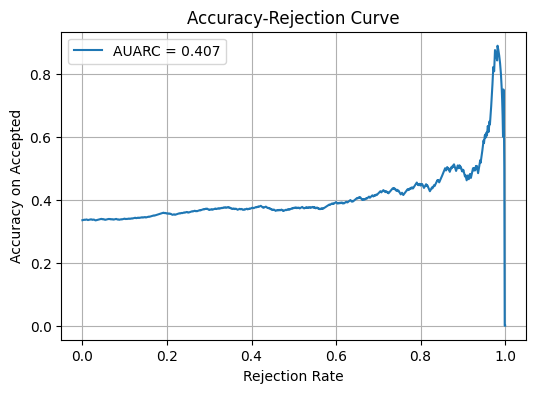

In [ ]:
import time
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# --- Ваш существующий код (чтение датасета, определение классов, инициализация модели) ---
# ...
test_df = pd.read_csv("test_grnti.csv")
print("Размер test:", test_df.shape)
print(test_df.head())


print("Классы:", classes)


# Параметры
M = 10
temperature = 1
N = len(test_df)   # можно взять весь датасет или его часть
sample_df = test_df.head(N)

results = []
start_time = time.time()

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    text = row['text']
    true_label = row['label']
    preds = generate_multiple_predictions(text, classes, M=M, temperature=temperature)
    metrics = consistency_metrics(preds)
    results.append({
        'text': text,
        'true_label': true_label,
        'predictions': preds,
        'majority_vote': metrics['majority_vote'],
        'confidence': metrics['confidence'],
        'entropy': metrics['entropy'],
        'unique_ratio': metrics['unique_ratio']
    })

end_time = time.time()
total_time = end_time - start_time
n_examples = len(sample_df)

results_df = pd.DataFrame(results)
results_df['is_correct'] = (results_df['majority_vote'] == results_df['true_label']).astype(int)

# --- Метрики качества ---
auroc_conf = roc_auc_score(results_df['is_correct'], results_df['confidence'])
max_entropy = np.log(len(classes))
results_df['certainty'] = 1 - results_df['entropy'] / max_entropy
auroc_entropy = roc_auc_score(results_df['is_correct'], results_df['certainty'])

print(f"AUROC (confidence): {auroc_conf:.4f}")
print(f"AUROC (certainty): {auroc_entropy:.4f}")

def compute_auarc(df, confidence_col='confidence', correct_col='is_correct'):
    sorted_df = df.sort_values(by=confidence_col, ascending=False).reset_index(drop=True)
    n = len(sorted_df)
    accuracies = []
    rejection_rates = []
    for k in range(n + 1):
        accepted = sorted_df.iloc[:n-k]
        if len(accepted) == 0:
            acc = 0.0
        else:
            acc = accepted[correct_col].mean()
        accuracies.append(acc)
        rejection_rates.append(k / n)
    auarc = np.trapz(accuracies, x=rejection_rates)
    return auarc, rejection_rates, accuracies

auarc_conf, rej_rates, acc_vals = compute_auarc(results_df, confidence_col='confidence')
print(f"AUARC (confidence): {auarc_conf:.4f}")

# --- Скорость инференса ---
print(f"\nВсего примеров: {n_examples}")
print(f"Всего генераций: {n_examples * M}")
print(f"Общее время: {total_time:.2f} сек")
print(f"Среднее на пример: {total_time / n_examples:.3f} сек")
print(f"Среднее на одну генерацию: {total_time / (n_examples * M):.3f} сек")

# --- (Опционально) График ARC ---
plt.figure(figsize=(6, 4))
plt.plot(rej_rates, acc_vals, label=f'AUARC = {auarc_conf:.3f}')
plt.xlabel('Rejection Rate')
plt.ylabel('Accuracy on Accepted')
plt.title('Accuracy-Rejection Curve')
plt.legend()
plt.grid(True)
plt.show()

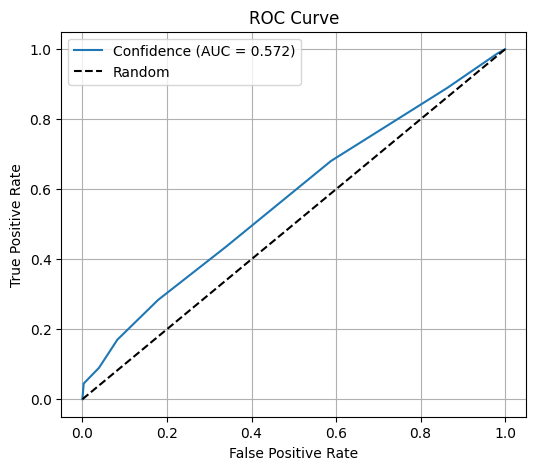

In [ ]:
from sklearn.metrics import roc_curve, auc

# ROC для confidence
fpr_conf, tpr_conf, _ = roc_curve(results_df['is_correct'], results_df['confidence'])
roc_auc_conf = auc(fpr_conf, tpr_conf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_conf, tpr_conf, label=f'Confidence (AUC = {roc_auc_conf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results_df

,text,true_label,predictions,majority_vote,confidence,entropy,unique_ratio,is_correct,certainty
0,ВЫСОКОВОЛЬТНЫЕ ЯВЛЕНИЯ В РАСПЛАВЛЕННЫХ ХЛОРИДН...,Химия,"[unknown, Химия, unknown, unknown, Энергетика,...",unknown,0.4,1.054920,0.3,0,0.541854
1,Каталитическое карбонилирование α-олефинов в п...,Химия,"[Математика, Химия, unknown, unknown, unknown,...",Химия,0.6,0.897946,0.3,1,0.610027
2,ВЛИЯНИЕ ТЕМПЕРАТУРЫ И КОНЦЕНТРАЦИИ НА ГИДРАТАЦ...,Химия,"[unknown, Физика, Химия, Биология, Химия, Мате...",Химия,0.3,1.695743,0.6,1,0.263548
3,ОПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ ДИФФУЗИИ АМЕРИЦИЯ И ...,Химия,"[Математика, unknown, Физика, Химия, unknown, ...",unknown,0.5,1.220607,0.4,0,0.469897
4,ОБЩЕЕ ПРЕДСТАВЛЕНИЕ О НУКЛЕАЗАХ ИЗ ЯДА ЗМЕЙ: Д...,Химия,"[unknown, unknown, Математика, Биология, Химия...",Биология,0.3,1.504788,0.5,0,0.346479
...,...,...,...,...,...,...,...,...,...
995,Демокрит и дата падения Трои. В статье рассмат...,Философия,"[unknown, Психология, Философия, unknown, Энер...",unknown,0.3,1.366159,0.4,0,0.406685
996,ФИЛОСОФИЯ ИСТОРИИ Н.А. БЕРДЯЕВА: ЭКЗИСТЕНЦИАЛЬ...,Философия,"[Философия, Философия, unknown, Философия, unk...",Философия,0.6,0.897946,0.3,1,0.610027
997,Проблема императивности в этике Аристотеля. Це...,Философия,"[Психология, Психология, Философия, Философия,...",Философия,0.6,0.950271,0.3,1,0.587303
998,Тактика вне стратегии. Военно-политическая раб...,Философия,"[unknown, unknown, unknown, Биология, unknown,...",unknown,0.9,0.325083,0.2,0,0.858818


In [ ]:
results_df["predictions"][:6]

,predictions
0,"[unknown, Химия, unknown, unknown, Энергетика,..."
1,"[Математика, Химия, unknown, unknown, unknown,..."
2,"[unknown, Физика, Химия, Биология, Химия, Мате..."
3,"[Математика, unknown, Физика, Химия, unknown, ..."
4,"[unknown, unknown, Математика, Биология, Химия..."
5,"[Математика, Химия, Биология, unknown, Биологи..."


# Self-Consistency, clinc, 0.5

In [ ]:
def create_prompt(text, classes):
    instruction = f"""Ты — эксперт по классификации итентов пользователя в чат боте.
Твоя задача — отнести запрос к одной из категорий: {', '.join(classes)}.

Ответь только одним словом — названием категории, без дополнительных слов, знаков препинания или форматирования.

Примеры:
Текст: Скажите мне пожалуйста какие прививки я должен сделать перед поездкой в Мексику?
Категория: вакцины

Текст: Мне нужны подробности по моим федеральным налогам
Категория: налоги

Теперь классифицируй следующий запрос:

Запрос: {text}

Категория:"""
    return instruction

In [ ]:
classes = [
    "баланс",
    "бензин",
    "рецепт",
    "музыка",
    "пробки",
    "перевод",
    "погода",
    "налоги",
    "вакцины",
    "напоминание"
]

In [ ]:
def extract_category(generated_text, classes):
    """
    Извлекает категорию из сгенерированного текста.
    Ищет первое вхождение любого класса из списка (регистронезависимо).
    Если не найдено, возвращает 'unknown'.
    """
    cleaned = generated_text.strip()
    # Ищем класс в тексте (можно убрать звёздочки, но не обязательно)
    for cls in classes:
        if cls.lower() in cleaned.lower():
            return cls
    return "unknown"

In [ ]:
def generate_single_prediction(text, classes, temperature=0.5, do_sample=True):
    prompt = create_prompt(text, classes)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=18,          # достаточно для одного слова
            temperature=temperature,
            do_sample=do_sample,
            pad_token_id=tokenizer.eos_token_id
        )
    generated = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    # Извлекаем категорию
    category = extract_category(generated, classes)
    return category

In [ ]:
def generate_multiple_predictions(text, classes, M=5, temperature=1.0):
    preds = []
    for _ in range(M):
        pred = generate_single_prediction(text, classes, temperature=temperature, do_sample=True)
        preds.append(pred)
    return preds

In [ ]:
from collections import Counter
import math

def consistency_metrics(predictions):
    """
    predictions: list of strings
    возвращает словарь с метриками
    """
    if not predictions:
        return {"majority_vote": None, "confidence": 0.0, "entropy": float('inf'), "unique_ratio": 1.0}

    counter = Counter(predictions)
    majority_class, majority_count = counter.most_common(1)[0]
    total = len(predictions)
    confidence = majority_count / total          # доля совпадающих с мажоритарным
    entropy = -sum((cnt/total) * math.log(cnt/total) for cnt in counter.values())
    unique_ratio = len(counter) / total          # доля уникальных ответов

    return {
        "majority_vote": majority_class,
        "confidence": confidence,
        "entropy": entropy,
        "unique_ratio": unique_ratio
    }

In [ ]:
def measure_inference_speed(text, classes, M=5, num_runs=5):
    """Измеряет среднее время выполнения M генераций для одного примера."""
    times = []
    for _ in range(num_runs):
        start = time.time()
        generate_multiple_predictions(text, classes, M=M)
        end = time.time()
        times.append(end - start)
    avg_time = np.mean(times)
    std_time = np.std(times)
    return avg_time, std_time

Размер test: (100, 3)
    id                                               text        label
0  297            Можешь найти мне рецепт медового хлеба?       рецепт
1  794                    Вы можете рассчитать мой налог?       налоги
2  805  Нужно ли мне делать прививки или что-то еще пе...      вакцины
3   46             что осталось на моих банковских счетах       баланс
4  998  Можете ли вы сказать мне все напоминания я уст...  напоминание
Классы: ['баланс', 'бензин', 'рецепт', 'музыка', 'пробки', 'перевод', 'погода', 'налоги', 'вакцины', 'напоминание']


100%|██████████| 100/100 [12:56<00:00,  7.76s/it]
/tmp/ipykernel_980/475896518.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auarc = np.trapz(accuracies, x=rejection_rates)


AUROC (confidence): 0.6961
AUROC (certainty): 0.7012
AUARC (confidence): 0.7762

Всего примеров: 100
Всего генераций: 1000
Общее время: 776.51 сек
Среднее на пример: 7.765 сек
Среднее на одну генерацию: 0.777 сек


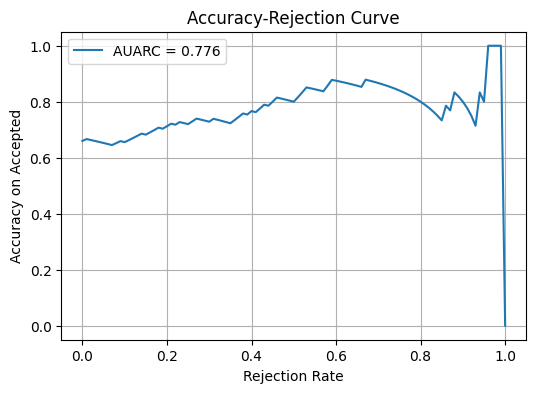

In [ ]:
import time
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# --- Ваш существующий код (чтение датасета, определение классов, инициализация модели) ---
# ...
test_df = pd.read_csv("test_c.csv")
print("Размер test:", test_df.shape)
print(test_df.head())


print("Классы:", classes)


# Параметры
M = 10
temperature = 0.5
N = len(test_df)   # можно взять весь датасет или его часть
sample_df = test_df.head(N)

results = []
start_time = time.time()

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    text = row['text']
    true_label = row['label']
    preds = generate_multiple_predictions(text, classes, M=M, temperature=temperature)
    metrics = consistency_metrics(preds)
    results.append({
        'text': text,
        'true_label': true_label,
        'predictions': preds,
        'majority_vote': metrics['majority_vote'],
        'confidence': metrics['confidence'],
        'entropy': metrics['entropy'],
        'unique_ratio': metrics['unique_ratio']
    })

end_time = time.time()
total_time = end_time - start_time
n_examples = len(sample_df)

results_df = pd.DataFrame(results)
results_df['is_correct'] = (results_df['majority_vote'] == results_df['true_label']).astype(int)

# --- Метрики качества ---
auroc_conf = roc_auc_score(results_df['is_correct'], results_df['confidence'])
max_entropy = np.log(len(classes))
results_df['certainty'] = 1 - results_df['entropy'] / max_entropy
auroc_entropy = roc_auc_score(results_df['is_correct'], results_df['certainty'])

print(f"AUROC (confidence): {auroc_conf:.4f}")
print(f"AUROC (certainty): {auroc_entropy:.4f}")

def compute_auarc(df, confidence_col='confidence', correct_col='is_correct'):
    sorted_df = df.sort_values(by=confidence_col, ascending=False).reset_index(drop=True)
    n = len(sorted_df)
    accuracies = []
    rejection_rates = []
    for k in range(n + 1):
        accepted = sorted_df.iloc[:n-k]
        if len(accepted) == 0:
            acc = 0.0
        else:
            acc = accepted[correct_col].mean()
        accuracies.append(acc)
        rejection_rates.append(k / n)
    auarc = np.trapz(accuracies, x=rejection_rates)
    return auarc, rejection_rates, accuracies

auarc_conf, rej_rates, acc_vals = compute_auarc(results_df, confidence_col='confidence')
print(f"AUARC (confidence): {auarc_conf:.4f}")

# --- Скорость инференса ---
print(f"\nВсего примеров: {n_examples}")
print(f"Всего генераций: {n_examples * M}")
print(f"Общее время: {total_time:.2f} сек")
print(f"Среднее на пример: {total_time / n_examples:.3f} сек")
print(f"Среднее на одну генерацию: {total_time / (n_examples * M):.3f} сек")

# --- (Опционально) График ARC ---
plt.figure(figsize=(6, 4))
plt.plot(rej_rates, acc_vals, label=f'AUARC = {auarc_conf:.3f}')
plt.xlabel('Rejection Rate')
plt.ylabel('Accuracy on Accepted')
plt.title('Accuracy-Rejection Curve')
plt.legend()
plt.grid(True)
plt.show()

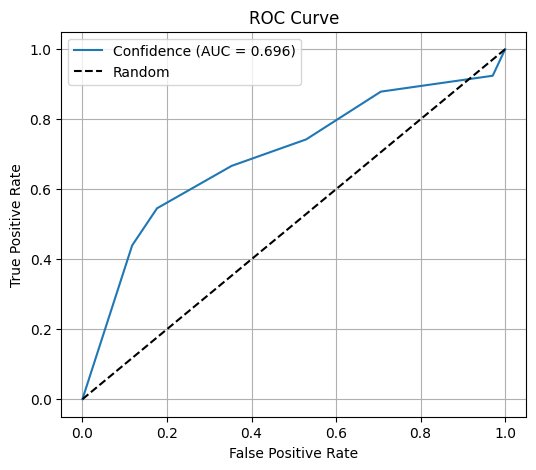

In [ ]:
from sklearn.metrics import roc_curve, auc

# ROC для confidence
fpr_conf, tpr_conf, _ = roc_curve(results_df['is_correct'], results_df['confidence'])
roc_auc_conf = auc(fpr_conf, tpr_conf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_conf, tpr_conf, label=f'Confidence (AUC = {roc_auc_conf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# # Загружаем датасет
# test_df = pd.read_csv("test_grnti.csv")
# print("Размер test:", test_df.shape)
# print(test_df.head())


# print("Классы:", classes)

# # Для теста возьмём первые N примеров
# N = len(test_df)  # можно изменить
# sample_df = test_df.head(N)

# # Параметры
# M = 10
# temperature = 0.5   # степень стохастичности

# # Сохраняем результаты
# results = []

# # Прогресс-бар
# for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
#     text = row['text']
#     true_label = row['label']

#     # Генерация M предсказаний
#     preds = generate_multiple_predictions(text, classes, M=M, temperature=temperature)

#     # Метрики согласованности
#     metrics = consistency_metrics(preds)

#     # Запоминаем
#     results.append({
#         'text': text,
#         'true_label': true_label,
#         'predictions': preds,
#         'majority_vote': metrics['majority_vote'],
#         'confidence': metrics['confidence'],
#         'entropy': metrics['entropy'],
#         'unique_ratio': metrics['unique_ratio']
#     })

# # Преобразуем в DataFrame для анализа
# results_df = pd.DataFrame(results)
# print(results_df[['true_label', 'majority_vote', 'confidence', 'entropy', 'unique_ratio']].head(10))

In [ ]:
results_df

,text,true_label,predictions,majority_vote,confidence,entropy,unique_ratio,is_correct,certainty
0,Можешь найти мне рецепт медового хлеба?,рецепт,"[рецепт, рецепт, рецепт, рецепт, рецепт, рецеп...",рецепт,1.0,-0.000000,0.1,1,1.000000
1,Вы можете рассчитать мой налог?,налоги,"[рецепт, рецепт, налоги, рецепт, налоги, налог...",налоги,0.6,0.673012,0.2,1,0.707715
2,Нужно ли мне делать прививки или что-то еще пе...,вакцины,"[unknown, unknown, unknown, unknown, unknown, ...",unknown,0.9,0.325083,0.2,0,0.858818
3,что осталось на моих банковских счетах,баланс,"[баланс, баланс, баланс, баланс, баланс, балан...",баланс,1.0,-0.000000,0.1,1,1.000000
4,Можете ли вы сказать мне все напоминания я уст...,напоминание,"[рецепт, рецепт, напоминание, рецепт, напомина...",рецепт,0.5,0.693147,0.2,0,0.698970
...,...,...,...,...,...,...,...,...,...
95,Скажите мне прогноз погоды на сегодняшний день,погода,"[рецепт, рецепт, рецепт, рецепт, рецепт, рецеп...",рецепт,1.0,-0.000000,0.1,0,1.000000
96,Будет ли сегодня вечером дождь?,погода,"[погода, погода, погода, погода, рецепт, рецеп...",погода,0.6,0.673012,0.2,1,0.707715
97,Как приготовить шотландское блюдо с кровью и к...,рецепт,"[рецепт, рецепт, рецепт, рецепт, рецепт, рецеп...",рецепт,0.9,0.325083,0.2,1,0.858818
98,Как я могу поблагодарить кого-то на итальянском?,перевод,"[перевод, перевод, перевод, перевод, перевод, ...",перевод,1.0,-0.000000,0.1,1,1.000000


In [ ]:
results_df["predictions"][:6]

,predictions
0,"[рецепт, рецепт, рецепт, рецепт, рецепт, рецеп..."
1,"[рецепт, рецепт, налоги, рецепт, налоги, налог..."
2,"[unknown, unknown, unknown, unknown, unknown, ..."
3,"[баланс, баланс, баланс, баланс, баланс, балан..."
4,"[рецепт, рецепт, напоминание, рецепт, напомина..."
5,"[пробки, пробки, пробки, рецепт, пробки, рецеп..."


# Self-Consistency, clinc, 1

In [4]:
def create_prompt(text, classes):
    instruction = f"""Ты — эксперт по классификации итентов пользователя в чат боте.
Твоя задача — отнести запрос к одной из категорий: {', '.join(classes)}.

Ответь только одним словом — названием категории, без дополнительных слов, знаков препинания или форматирования.

Примеры:
Текст: Скажите мне пожалуйста какие прививки я должен сделать перед поездкой в Мексику?
Категория: вакцины

Текст: Мне нужны подробности по моим федеральным налогам
Категория: налоги

Теперь классифицируй следующий запрос:

Запрос: {text}

Категория:"""
    return instruction

In [5]:
classes = [
    "баланс",
    "бензин",
    "рецепт",
    "музыка",
    "пробки",
    "перевод",
    "погода",
    "налоги",
    "вакцины",
    "напоминание"
]

In [6]:
def extract_category(generated_text, classes):
    """
    Извлекает категорию из сгенерированного текста.
    Ищет первое вхождение любого класса из списка (регистронезависимо).
    Если не найдено, возвращает 'unknown'.
    """
    cleaned = generated_text.strip()
    # Ищем класс в тексте (можно убрать звёздочки, но не обязательно)
    for cls in classes:
        if cls.lower() in cleaned.lower():
            return cls
    return "unknown"

In [7]:
def generate_single_prediction(text, classes, temperature=1, do_sample=True):
    prompt = create_prompt(text, classes)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=18,          # достаточно для одного слова
            temperature=temperature,
            do_sample=do_sample,
            pad_token_id=tokenizer.eos_token_id
        )
    generated = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    # Извлекаем категорию
    category = extract_category(generated, classes)
    return category

In [8]:
def generate_multiple_predictions(text, classes, M=5, temperature=1.0):
    preds = []
    for _ in range(M):
        pred = generate_single_prediction(text, classes, temperature=temperature, do_sample=True)
        preds.append(pred)
    return preds

In [9]:
from collections import Counter
import math

def consistency_metrics(predictions):
    """
    predictions: list of strings
    возвращает словарь с метриками
    """
    if not predictions:
        return {"majority_vote": None, "confidence": 0.0, "entropy": float('inf'), "unique_ratio": 1.0}

    counter = Counter(predictions)
    majority_class, majority_count = counter.most_common(1)[0]
    total = len(predictions)
    confidence = majority_count / total          # доля совпадающих с мажоритарным
    entropy = -sum((cnt/total) * math.log(cnt/total) for cnt in counter.values())
    unique_ratio = len(counter) / total          # доля уникальных ответов

    return {
        "majority_vote": majority_class,
        "confidence": confidence,
        "entropy": entropy,
        "unique_ratio": unique_ratio
    }

In [10]:
def measure_inference_speed(text, classes, M=5, num_runs=5):
    """Измеряет среднее время выполнения M генераций для одного примера."""
    times = []
    for _ in range(num_runs):
        start = time.time()
        generate_multiple_predictions(text, classes, M=M)
        end = time.time()
        times.append(end - start)
    avg_time = np.mean(times)
    std_time = np.std(times)
    return avg_time, std_time

Размер test: (100, 3)
    id                                               text        label
0  297            Можешь найти мне рецепт медового хлеба?       рецепт
1  794                    Вы можете рассчитать мой налог?       налоги
2  805  Нужно ли мне делать прививки или что-то еще пе...      вакцины
3   46             что осталось на моих банковских счетах       баланс
4  998  Можете ли вы сказать мне все напоминания я уст...  напоминание
Классы: ['баланс', 'бензин', 'рецепт', 'музыка', 'пробки', 'перевод', 'погода', 'налоги', 'вакцины', 'напоминание']


100%|██████████| 100/100 [12:57<00:00,  7.78s/it]
/tmp/ipykernel_2620/532131203.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auarc = np.trapz(accuracies, x=rejection_rates)


AUROC (confidence): 0.8181
AUROC (certainty): 0.8103
AUARC (confidence): 0.9047

Всего примеров: 100
Всего генераций: 1000
Общее время: 777.79 сек
Среднее на пример: 7.778 сек
Среднее на одну генерацию: 0.778 сек


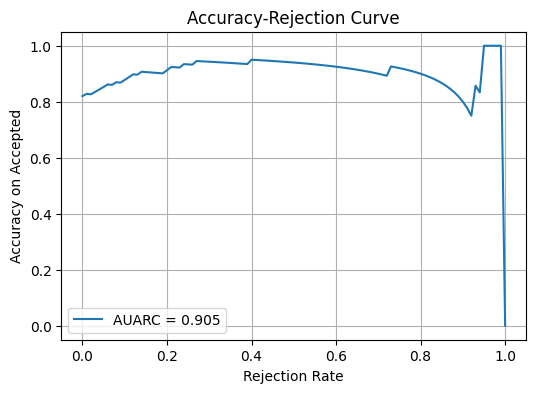

In [11]:
import time
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# --- Ваш существующий код (чтение датасета, определение классов, инициализация модели) ---
# ...
test_df = pd.read_csv("test_c.csv")
print("Размер test:", test_df.shape)
print(test_df.head())


print("Классы:", classes)


# Параметры
M = 10
temperature = 1
N = len(test_df)   # можно взять весь датасет или его часть
sample_df = test_df.head(N)

results = []
start_time = time.time()

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    text = row['text']
    true_label = row['label']
    preds = generate_multiple_predictions(text, classes, M=M, temperature=temperature)
    metrics = consistency_metrics(preds)
    results.append({
        'text': text,
        'true_label': true_label,
        'predictions': preds,
        'majority_vote': metrics['majority_vote'],
        'confidence': metrics['confidence'],
        'entropy': metrics['entropy'],
        'unique_ratio': metrics['unique_ratio']
    })

end_time = time.time()
total_time = end_time - start_time
n_examples = len(sample_df)

results_df = pd.DataFrame(results)
results_df['is_correct'] = (results_df['majority_vote'] == results_df['true_label']).astype(int)

# --- Метрики качества ---
auroc_conf = roc_auc_score(results_df['is_correct'], results_df['confidence'])
max_entropy = np.log(len(classes))
results_df['certainty'] = 1 - results_df['entropy'] / max_entropy
auroc_entropy = roc_auc_score(results_df['is_correct'], results_df['certainty'])

print(f"AUROC (confidence): {auroc_conf:.4f}")
print(f"AUROC (certainty): {auroc_entropy:.4f}")

def compute_auarc(df, confidence_col='confidence', correct_col='is_correct'):
    sorted_df = df.sort_values(by=confidence_col, ascending=False).reset_index(drop=True)
    n = len(sorted_df)
    accuracies = []
    rejection_rates = []
    for k in range(n + 1):
        accepted = sorted_df.iloc[:n-k]
        if len(accepted) == 0:
            acc = 0.0
        else:
            acc = accepted[correct_col].mean()
        accuracies.append(acc)
        rejection_rates.append(k / n)
    auarc = np.trapz(accuracies, x=rejection_rates)
    return auarc, rejection_rates, accuracies

auarc_conf, rej_rates, acc_vals = compute_auarc(results_df, confidence_col='confidence')
print(f"AUARC (confidence): {auarc_conf:.4f}")

# --- Скорость инференса ---
print(f"\nВсего примеров: {n_examples}")
print(f"Всего генераций: {n_examples * M}")
print(f"Общее время: {total_time:.2f} сек")
print(f"Среднее на пример: {total_time / n_examples:.3f} сек")
print(f"Среднее на одну генерацию: {total_time / (n_examples * M):.3f} сек")

# --- (Опционально) График ARC ---
plt.figure(figsize=(6, 4))
plt.plot(rej_rates, acc_vals, label=f'AUARC = {auarc_conf:.3f}')
plt.xlabel('Rejection Rate')
plt.ylabel('Accuracy on Accepted')
plt.title('Accuracy-Rejection Curve')
plt.legend()
plt.grid(True)
plt.show()

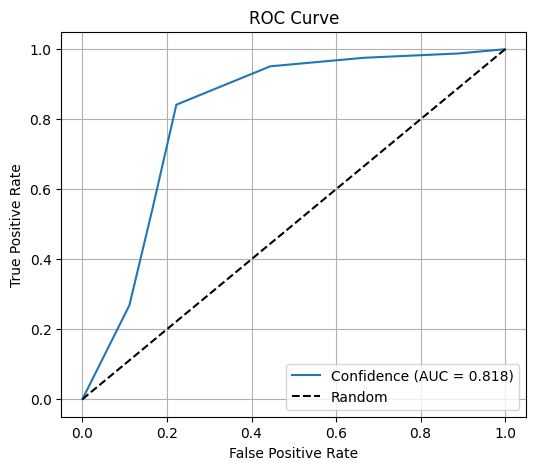

In [12]:
from sklearn.metrics import roc_curve, auc

# ROC для confidence
fpr_conf, tpr_conf, _ = roc_curve(results_df['is_correct'], results_df['confidence'])
roc_auc_conf = auc(fpr_conf, tpr_conf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_conf, tpr_conf, label=f'Confidence (AUC = {roc_auc_conf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
results_df

,text,true_label,predictions,majority_vote,confidence,entropy,unique_ratio,is_correct,certainty
0,Можешь найти мне рецепт медового хлеба?,рецепт,"[рецепт, рецепт, рецепт, рецепт, рецепт, рецеп...",рецепт,1.0,-0.000000,0.1,1,1.000000
1,Вы можете рассчитать мой налог?,налоги,"[налоги, рецепт, налоги, налоги, налоги, налог...",налоги,0.9,0.325083,0.2,1,0.858818
2,Нужно ли мне делать прививки или что-то еще пе...,вакцины,"[вакцины, unknown, рецепт, unknown, unknown, u...",unknown,0.7,0.801819,0.3,0,0.651775
3,что осталось на моих банковских счетах,баланс,"[баланс, баланс, баланс, баланс, баланс, балан...",баланс,1.0,-0.000000,0.1,1,1.000000
4,Можете ли вы сказать мне все напоминания я уст...,напоминание,"[напоминание, напоминание, напоминание, unknow...",напоминание,0.8,0.639032,0.3,1,0.722472
...,...,...,...,...,...,...,...,...,...
95,Скажите мне прогноз погоды на сегодняшний день,погода,"[рецепт, погода, погода, погода, погода, погод...",погода,0.7,0.801819,0.3,1,0.651775
96,Будет ли сегодня вечером дождь?,погода,"[погода, бензин, погода, погода, погода, погод...",погода,0.8,0.639032,0.3,1,0.722472
97,Как приготовить шотландское блюдо с кровью и к...,рецепт,"[рецепт, рецепт, рецепт, рецепт, рецепт, рецеп...",рецепт,1.0,-0.000000,0.1,1,1.000000
98,Как я могу поблагодарить кого-то на итальянском?,перевод,"[unknown, перевод, перевод, перевод, перевод, ...",перевод,0.8,0.500402,0.2,1,0.782678


In [14]:
results_df["predictions"][:6]

,predictions
0,"[рецепт, рецепт, рецепт, рецепт, рецепт, рецеп..."
1,"[налоги, рецепт, налоги, налоги, налоги, налог..."
2,"[вакцины, unknown, рецепт, unknown, unknown, u..."
3,"[баланс, баланс, баланс, баланс, баланс, балан..."
4,"[напоминание, напоминание, напоминание, unknow..."
5,"[погода, пробки, пробки, пробки, unknown, пого..."
